In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder ,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostClassifier, Pool 

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# load dataset

In [3]:
df = pd.read_csv("synthetic_health_dataset.csv")
df.head()

,Gender,Smoking,Alcohol_Consumption,Exercise_Frequency,Blood_Pressure,Cholesterol_Level,Stress_Level,Age,BMI,Heart_Rate,Sleep_Hours,Blood_Sugar_Level,Medication_Use,Family_History,Illness
0,Fe__Male__,No,Moderate,Never,0Normal102,Borderline,High,"""90""",16.6,119,3.6,143.6,NaN,No,Yes
1,Other,Yes,NaN,Never,0Normal102,0Normal102,Low,20,29.9,69,9.9,121.8,NaN,Yes,No
2,__Male__,Yes,Heavy,Daily,High,High,Low,52,33.5,54,8.5,107,NaN,Yes,Yes
3,__Male__,Yes,Heavy,Daily,0Normal102,High,Low,15,20.3,72,9.5,92.1,NaN,No,Yes
4,__Male__,No,Moderate,Often,High,High,Medium,60,36.0,58,4.4,113.6,NaN,No,Yes


# DATA CLEANING

In [4]:
df.columns

Index(['Gender', 'Smoking', 'Alcohol_Consumption', 'Exercise_Frequency',
       'Blood_Pressure', 'Cholesterol_Level', 'Stress_Level', 'Age', 'BMI',
       'Heart_Rate', 'Sleep_Hours', 'Blood_Sugar_Level', 'Medication_Use',
       'Family_History', 'Illness'],
      dtype='object')

In [5]:
column_mapping = {
    'Gender': 'Gender',
    'Smoking': 'Smoking',
    'hol_Consump': 'Alcohol_Consumption',
    'rcise_Freque': 'Exercise_Frequency',
    'lood_Pressur': 'Blood_Pressure',
    'olesterol_Lev': 'Cholesterol_Level',
    'Stress_Level': 'Stress_Level',
    'Age': 'Age',
    'BMI': 'BMI',
    'Heart_Rate': 'Heart_Rate',
    'Sleep_Hours': 'Sleep_Hours',
    'od_Sugar_Leve': 'Blood_Sugar_Level',
    'edication_Usa': 'Medication_Usage',
    'amily_Histor': 'Family_History',
    'Illne': 'Illness'
}
df.rename(columns=column_mapping, inplace=True)

In [6]:
df.head()

,Gender,Smoking,Alcohol_Consumption,Exercise_Frequency,Blood_Pressure,Cholesterol_Level,Stress_Level,Age,BMI,Heart_Rate,Sleep_Hours,Blood_Sugar_Level,Medication_Use,Family_History,Illness
0,Fe__Male__,No,Moderate,Never,0Normal102,Borderline,High,"""90""",16.6,119,3.6,143.6,NaN,No,Yes
1,Other,Yes,NaN,Never,0Normal102,0Normal102,Low,20,29.9,69,9.9,121.8,NaN,Yes,No
2,__Male__,Yes,Heavy,Daily,High,High,Low,52,33.5,54,8.5,107,NaN,Yes,Yes
3,__Male__,Yes,Heavy,Daily,0Normal102,High,Low,15,20.3,72,9.5,92.1,NaN,No,Yes
4,__Male__,No,Moderate,Often,High,High,Medium,60,36.0,58,4.4,113.6,NaN,No,Yes


In [7]:
df["Gender"].value_counts()

Gender
__Male__      336
Fe__Male__    326
Other         326
Name: count, dtype: int64

In [8]:
#  Clean string values in 'Gender' 
df['Gender'] = df['Gender'].astype(str).str.replace('__', '', regex=False)
df['Gender'] = df['Gender'].replace({'FeMale': 'Female', 'Male': 'Male', 'Other': 'Other', 'nan': np.nan})

In [15]:
df["Gender"].value_counts()

Gender
Male      336
Female    326
Other     326
Name: count, dtype: int64

In [9]:
df["Blood_Pressure"].value_counts()

Blood_Pressure
0Normal102    342
Low           336
High          312
Name: count, dtype: int64

In [10]:
df["Cholesterol_Level"].value_counts()

Cholesterol_Level
High          342
Borderline    340
0Normal102    311
Name: count, dtype: int64

In [11]:
df["Blood_Pressure"] = df["Blood_Pressure"].replace('0Normal102', 'Normal')
df["Cholesterol_Level"] = df["Cholesterol_Level"].replace('0Normal102', 'Normal')

In [13]:
df["Cholesterol_Level"].value_counts()

Cholesterol_Level
High          342
Borderline    340
Normal        311
Name: count, dtype: int64

#  Clean 'Age' column 

In [15]:
#  Clean 'Age' column 
df['Age'] = df['Age'].astype(str).str.replace('"', '', regex=False).str.replace("'", "", regex=False)
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

In [17]:
df["Age"].dtype

dtype('float64')

In [26]:
df['Heart_Rate'] = pd.to_numeric(df['Heart_Rate'], errors='coerce')
df['Blood_Sugar_Level'] = pd.to_numeric(df['Blood_Sugar_Level'], errors='coerce')

In [30]:
df["Medication_Use"].value_counts()

Medication_Use
Occasional       344
Regular          308
Regular____        2
Occasional___      1
Name: count, dtype: int64

In [31]:
df['Medication_Use'] = df['Medication_Use'].astype(str).str.rstrip('_')
df['Medication_Use'] = df['Medication_Use'].replace('nan', np.nan)

#  Fill the missing values with the most common category (Mode)
med_mode = df['Medication_Use'].mode()[0]
df['Medication_Use'] = df['Medication_Use'].fillna(med_mode)

In [32]:
df["Medication_Use"].value_counts()

Medication_Use
Occasional    690
Regular       310
Name: count, dtype: int64

In [33]:
df["Exercise_Frequency"].value_counts()

Exercise_Frequency
Never     258
Daily     248
Often     248
Rarely    239
Name: count, dtype: int64

In [34]:
df.nunique()

Gender                   3
Smoking                  2
Alcohol_Consumption      2
Exercise_Frequency       4
Blood_Pressure           3
Cholesterol_Level        3
Stress_Level             3
Age                    100
BMI                    248
Heart_Rate              70
Sleep_Hours             71
Blood_Sugar_Level      661
Medication_Use           2
Family_History           2
Illness                  2
dtype: int64

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Gender               988 non-null    object 
 1   Smoking              993 non-null    object 
 2   Alcohol_Consumption  649 non-null    object 
 3   Exercise_Frequency   993 non-null    object 
 4   Blood_Pressure       990 non-null    object 
 5   Cholesterol_Level    993 non-null    object 
 6   Stress_Level         995 non-null    object 
 7   Age                  990 non-null    float64
 8   BMI                  992 non-null    float64
 9   Heart_Rate           991 non-null    float64
 10  Sleep_Hours          992 non-null    float64
 11  Blood_Sugar_Level    978 non-null    float64
 12  Medication_Use       655 non-null    object 
 13  Family_History       995 non-null    object 
 14  Illness              1000 non-null   object 
dtypes: float64(5), object(10)
memory usage:

In [37]:
df.duplicated().sum()


np.int64(0)

In [38]:
df.isna().sum()

Gender                  12
Smoking                  7
Alcohol_Consumption    351
Exercise_Frequency       7
Blood_Pressure          10
Cholesterol_Level        7
Stress_Level             5
Age                     10
BMI                      8
Heart_Rate               9
Sleep_Hours              8
Blood_Sugar_Level       22
Medication_Use           0
Family_History           5
Illness                  0
dtype: int64

In [40]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("🤖  Numerical :", numerical_cols)
print("🤖  Categorical :", categorical_cols)

🤖  Numerical : ['Age', 'BMI', 'Heart_Rate', 'Sleep_Hours', 'Blood_Sugar_Level']
🤖  Categorical : ['Gender', 'Smoking', 'Alcohol_Consumption', 'Exercise_Frequency', 'Blood_Pressure', 'Cholesterol_Level', 'Stress_Level', 'Medication_Use', 'Family_History', 'Illness']


In [41]:
# Fill all detected numerical columns with their respective Medians
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill all detected categorical columns with their respective Modes
for col in categorical_cols:
    # Ensure there is a mode available to prevent crashes on completely empty columns
    if not df[col].mode().empty:
        df[col] = df[col].fillna(df[col].mode()[0])

In [42]:
df.isnull().sum()

Gender                 0
Smoking                0
Alcohol_Consumption    0
Exercise_Frequency     0
Blood_Pressure         0
Cholesterol_Level      0
Stress_Level           0
Age                    0
BMI                    0
Heart_Rate             0
Sleep_Hours            0
Blood_Sugar_Level      0
Medication_Use         0
Family_History         0
Illness                0
dtype: int64

# Encoding

In [43]:
# 1. Find all columns that are still text/object type
categorical_cols = df.select_dtypes(include=['object']).columns

# 2. Apply LabelEncoder to each of them
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Preview the completely numeric dataset
df.head()

,Gender,Smoking,Alcohol_Consumption,Exercise_Frequency,Blood_Pressure,Cholesterol_Level,Stress_Level,Age,BMI,Heart_Rate,Sleep_Hours,Blood_Sugar_Level,Medication_Use,Family_History,Illness
0,0,0,1,1,2,0,0,90.0,16.6,119.0,3.6,143.6,0,0,1
1,2,1,1,1,2,2,1,20.0,29.9,69.0,9.9,121.8,0,1,0
2,1,1,0,0,0,1,1,52.0,33.5,54.0,8.5,107.0,0,1,1
3,1,1,0,0,2,1,1,15.0,20.3,72.0,9.5,92.1,0,0,1
4,1,0,1,2,0,1,2,60.0,36.0,58.0,4.4,113.6,0,0,1


In [45]:
df.corr()

,Gender,Smoking,Alcohol_Consumption,Exercise_Frequency,Blood_Pressure,Cholesterol_Level,Stress_Level,Age,BMI,Heart_Rate,Sleep_Hours,Blood_Sugar_Level,Medication_Use,Family_History,Illness
Gender,1.000000,-0.004957,0.037390,-0.050383,0.019782,-0.036862,-0.042099,-0.041293,0.091444,-0.030263,-0.024167,0.004913,0.018744,0.064432,-0.054502
Smoking,-0.004957,1.000000,-0.007859,-0.014245,0.009048,0.000017,-0.019171,-0.004534,0.034312,-0.045132,0.020960,-0.013936,-0.016139,-0.015104,-0.026701
Alcohol_Consumption,0.037390,-0.007859,1.000000,-0.033896,-0.022469,0.021190,-0.018848,0.034261,-0.049361,-0.006651,0.013701,0.009898,0.023454,-0.028083,0.018852
Exercise_Frequency,-0.050383,-0.014245,-0.033896,1.000000,0.010975,-0.011367,0.029628,-0.035734,0.007177,-0.015258,0.012422,0.016986,-0.012080,-0.038627,-0.022100
Blood_Pressure,0.019782,0.009048,-0.022469,0.010975,1.000000,0.007863,-0.032936,0.037271,-0.013176,-0.001718,-0.019087,-0.050772,-0.022316,-0.013178,0.013272
Cholesterol_Level,-0.036862,0.000017,0.021190,-0.011367,0.007863,1.000000,0.017064,0.039467,-0.020709,-0.042406,-0.023479,0.024833,-0.021479,-0.017282,0.010445
Stress_Level,-0.042099,-0.019171,-0.018848,0.029628,-0.032936,0.017064,1.000000,-0.008882,-0.009171,-0.023803,0.059568,-0.033830,-0.046909,0.051337,0.022513
Age,-0.041293,-0.004534,0.034261,-0.035734,0.037271,0.039467,-0.008882,1.000000,-0.019265,-0.007689,-0.034925,-0.046519,0.005209,-0.042467,0.021581
BMI,0.091444,0.034312,-0.049361,0.007177,-0.013176,-0.020709,-0.009171,-0.019265,1.000000,-0.021830,0.002878,0.033677,0.028754,0.037044,0.044299
Heart_Rate,-0.030263,-0.045132,-0.006651,-0.015258,-0.001718,-0.042406,-0.023803,-0.007689,-0.021830,1.000000,-0.011631,-0.022109,-0.018121,0.043816,0.038305


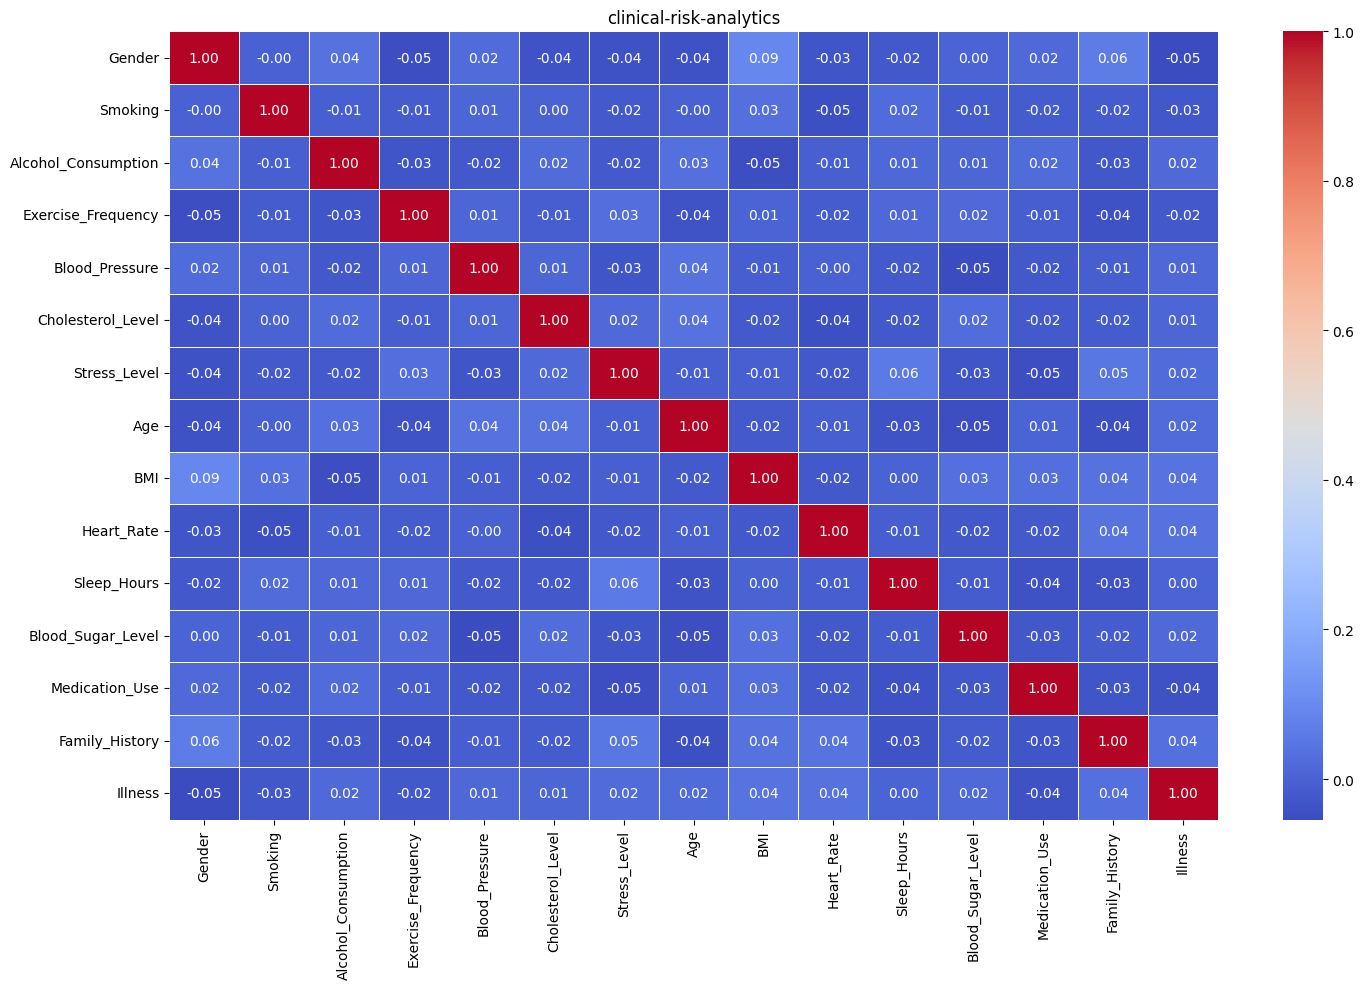

In [47]:

# 1. Set the figure size BEFORE creating the plot
plt.figure(figsize=(15, 10))

# 2. Use your correlation matrix (replace df.corr() if needed)
# annot=True shows the values, fmt=".2f" keeps them at 2 decimal places
# cmap='coolwarm' is a standard color palette for correlations
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# 3. Add titles and labels
plt.title('clinical-risk-analytics')

# 4. Display the plot
plt.tight_layout() # Ensures the labels aren't cut off
plt.show()

In [48]:
df.describe()

,Gender,Smoking,Alcohol_Consumption,Exercise_Frequency,Blood_Pressure,Cholesterol_Level,Stress_Level,Age,BMI,Heart_Rate,Sleep_Hours,Blood_Sugar_Level,Medication_Use,Family_History,Illness
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1.000000,0.483000,0.687000,1.47800,1.040000,0.971000,0.977000,49.532000,27.406000,85.054000,6.585600,135.741500,0.310000,0.484000,0.49000
std,0.807869,0.499961,0.463946,1.10668,0.814287,0.806728,0.824106,28.685987,7.206546,20.143954,2.030309,36.455053,0.462725,0.499994,0.50015
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,15.100000,50.000000,3.000000,70.200000,0.000000,0.000000,0.00000
25%,0.000000,0.000000,0.000000,1.00000,0.000000,0.000000,0.000000,24.000000,21.100000,68.000000,4.800000,106.175000,0.000000,0.000000,0.00000
50%,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,1.000000,50.000000,27.350000,85.000000,6.600000,136.550000,0.000000,0.000000,0.00000
75%,2.000000,1.000000,1.000000,2.00000,2.000000,2.000000,2.000000,75.000000,33.525000,103.000000,8.400000,167.450000,1.000000,1.000000,1.00000
max,2.000000,1.000000,1.000000,3.00000,2.000000,2.000000,2.000000,99.000000,40.000000,119.000000,10.000000,200.000000,1.000000,1.000000,1.00000


<Axes: ylabel='Illness'>

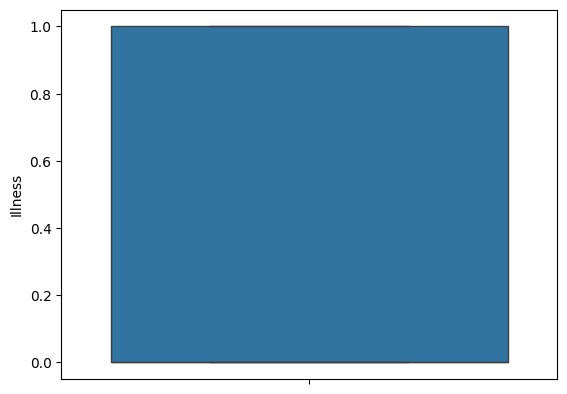

In [49]:
sns.boxplot(df["Illness"])

# re asambled dependent and independent variables

In [51]:
x = df.drop(columns=["Illness"])
y = df["Illness"]

In [52]:
x.head()

,Gender,Smoking,Alcohol_Consumption,Exercise_Frequency,Blood_Pressure,Cholesterol_Level,Stress_Level,Age,BMI,Heart_Rate,Sleep_Hours,Blood_Sugar_Level,Medication_Use,Family_History
0,0,0,1,1,2,0,0,90.0,16.6,119.0,3.6,143.6,0,0
1,2,1,1,1,2,2,1,20.0,29.9,69.0,9.9,121.8,0,1
2,1,1,0,0,0,1,1,52.0,33.5,54.0,8.5,107.0,0,1
3,1,1,0,0,2,1,1,15.0,20.3,72.0,9.5,92.1,0,0
4,1,0,1,2,0,1,2,60.0,36.0,58.0,4.4,113.6,0,0
